# 2-bit quantizer sample-size experiment

This notebook follows the Topic 06 sample-size workflow: choose confidence and power, estimate the standard deviation with a pilot run, then calculate how many paired observations are needed.

The three active algorithms are Leech shell-13, uniform scalar 2-bit, and QTIP bitshift K=2. E8 and RaBitQ are intentionally excluded. The final analysis uses multiple-sample tests first, followed by planned Bonferroni-corrected post-hoc paired comparisons.

In [94]:
from __future__ import annotations

import contextlib
import importlib.util
import io
import json
import math
import random
import subprocess
import sys
import time
import types
from dataclasses import dataclass
from pathlib import Path

import numpy as np

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

try:
    import torch
    TORCH_AVAILABLE = True
    TORCH_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
except Exception as exc:
    torch = None
    TORCH_AVAILABLE = False
    TORCH_IMPORT_ERROR = exc
    TORCH_DEVICE = None

try:
    import pandas as pd
except Exception:
    pd = None

import matplotlib.pyplot as plt


def seed_everything(seed: int):
    random.seed(int(seed))
    np.random.seed(int(seed))
    if TORCH_AVAILABLE:
        torch.manual_seed(int(seed))
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(int(seed))
        if hasattr(torch.backends, "cudnn"):
            torch.backends.cudnn.benchmark = False
            torch.backends.cudnn.deterministic = True


print(f"root: {ROOT}")
print(f"torch available: {TORCH_AVAILABLE}")
print(f"torch device: {TORCH_DEVICE}")


root: /home/diego/Documents/master/llm-quantization-benchmarks
torch available: True
torch device: cuda


In [ ]:
# Experiment configuration.
SEED = 0
DIM = 24
TARGET_BITS_PER_DIM = 2.0

# Algorithms: Leech shell-13, uniform scalar 2-bit, and QTIP bitshift K=2.
LEECH_MAX_SHELL = 13
LEECH_ANN_TOP_SHELLS = 0
QTIP_REPO = ROOT / "third_party" / "qtip"
AUTO_CLONE_QTIP = True
QTIP_GIT_URL = "https://github.com/Cornell-RelaxML/qtip.git"
QTIP_CONFIG = dict(L=8, K=int(TARGET_BITS_PER_DIM), V=1, tlut_bits=8, decode_mode="quantlut")

# No external/global scale in this experiment.
USE_SHARED_SCALE = False
SCALE_BITS = 0
SCALE_GRANULARITY = "none"
PER_VECTOR_SCALAR_BITS = 0

# Sample size calculation settings from the lecture: alpha, power, SD, and minimum interesting effect.
# One run/block is one vector evaluated by every algorithm.
# Each run records MSE, SQNR, quantize time, and dequantize time from the same quantize/dequantize call.
PILOT_QUALITY_N = 30
PILOT_TIMING_REPEATS = 30
TIMING_WARMUP_REPEATS = 5
TIMING_RANDOMIZE_ORDER = True


ALPHA = 0.05
POWER = 0.80

TWO_SIDED = True
# Controls post-hoc Type-I error. "all_metrics" controls all 3 metrics x 3 comparisons together.
# Use "per_metric" to control each metric family separately.
FWER_SCOPE = "all_metrics"
N_METRICS_FOR_FWER = 3
MHT_CORRECTION_METHOD = "bonferroni"  # "bonferroni" or "sidak"

# ANOVA omnibus sample-size scenarios from Topic 06.
ANOVA_EFFECT_SCENARIOS = ("two_levels_symmetric", "one_vs_rest")

# Minimum interesting effects. Adjust these to match the claim you want to make.
MIN_INTERESTING_SQNR_BITS_DIFF = 0.10
MIN_INTERESTING_QUANTIZE_SECONDS = 0.001
MIN_INTERESTING_DEQUANTIZE_SECONDS = 0.00005

# CSV output. Each top-to-bottom notebook execution writes exactly two raw data files in this run directory.
RESULTS_DIR = ROOT / "results" / "quantizer_sample_size_experiment"
RUN_ID = f"seed{SEED}_{time.strftime('%Y%m%d_%H%M%S')}"
RUN_DIR = RESULTS_DIR / RUN_ID


def make_rng(offset: int = 0):
    return np.random.default_rng(SEED + int(offset))


seed_everything(SEED)


In [96]:
@dataclass
class QuantizerReport:
    method: str
    rate_bits_per_dim: float
    mse: float
    rmse: float
    error_std: float
    squared_error_std: float
    sqnr_bits: float
    scale: float
    seconds: float
    quantize_seconds: float
    dequantize_seconds: float
    metadata: dict


def mse_to_sqnr_bits(mse: float) -> float:
    return float("inf") if mse == 0 else -0.5 * math.log2(mse)


def reconstruction_error_stats(x: np.ndarray, recon: np.ndarray) -> dict[str, float]:
    error = x - recon
    squared_error = error ** 2
    mse = float(np.mean(squared_error))
    return {
        "mse": mse,
        "rmse": float(math.sqrt(mse)),
        "error_std": float(np.std(error)),
        "squared_error_std": float(np.std(squared_error)),
    }


def synchronize_for_timing():
    if TORCH_AVAILABLE and torch.cuda.is_available():
        torch.cuda.synchronize()


def scale_overhead_bpd(x: np.ndarray, scale_bits: int, granularity: str) -> float:
    if scale_bits <= 0:
        return 0.0
    if granularity == "global":
        return float(scale_bits) / float(x.size)
    if granularity == "per_vector":
        return float(scale_bits) / float(x.shape[-1])
    raise ValueError(f"unknown scale granularity: {granularity}")


def optimize_global_scale(x: np.ndarray, quantize_normalized, scales: np.ndarray):
    best_scale = float(scales[0])
    best_mse = float("inf")
    best_recon = None
    for scale in scales:
        recon, mse = quantize_at_scale(x, quantize_normalized, float(scale))
        if mse < best_mse:
            best_scale = float(scale)
            best_mse = mse
            best_recon = recon
    return best_scale, best_mse, best_recon


def quantize_at_scale(x: np.ndarray, quantize_normalized, scale: float):
    recon = float(scale) * quantize_normalized(x / float(scale))
    stats = reconstruction_error_stats(x, recon)
    return recon, stats["mse"]


def choose_shared_scale(x: np.ndarray, quantizers, scales: np.ndarray):
    best_scale = float(scales[0])
    best_mean_mse = float("inf")
    for scale in scales:
        mses = [quantize_at_scale(x, item["quantize"], float(scale))[1] for item in quantizers]
        mean_mse = float(np.mean(mses))
        if mean_mse < best_mean_mse:
            best_scale = float(scale)
            best_mean_mse = mean_mse
    return best_scale, best_mean_mse


def run_scaled_quantizer(method: str, x: np.ndarray, rate: float, quantize_normalized, scales, metadata=None, shared_scale=None):
    metadata = {} if metadata is None else dict(metadata)
    start = time.perf_counter()
    if shared_scale is None:
        scale, mse, recon = optimize_global_scale(x, quantize_normalized, np.asarray(scales, dtype=np.float32))
        metadata.setdefault("scale_mode", "per_method_optimized")
    else:
        scale = float(shared_scale)
        recon, mse = quantize_at_scale(x, quantize_normalized, scale)
        metadata.setdefault("scale_mode", "shared")
    seconds = time.perf_counter() - start
    stats = reconstruction_error_stats(x, recon)
    report = QuantizerReport(
        method=method,
        rate_bits_per_dim=float(rate),
        mse=stats["mse"],
        rmse=stats["rmse"],
        error_std=stats["error_std"],
        squared_error_std=stats["squared_error_std"],
        sqnr_bits=mse_to_sqnr_bits(stats["mse"]),
        scale=float(scale),
        seconds=float(seconds),
        quantize_seconds=float(seconds),
        dequantize_seconds=0.0,
        metadata=metadata,
    )
    return report, recon


def run_split_scaled_quantizer(method: str, x: np.ndarray, rate: float, encode_normalized, decode_normalized, metadata=None, shared_scale=1.0):
    metadata = {} if metadata is None else dict(metadata)
    metadata.setdefault("scale_mode", "shared")
    scale = float(shared_scale)
    normalized = x / scale

    synchronize_for_timing()
    quantize_start = time.perf_counter()
    codes = encode_normalized(normalized)
    synchronize_for_timing()
    quantize_seconds = time.perf_counter() - quantize_start

    synchronize_for_timing()
    dequantize_start = time.perf_counter()
    recon_normalized = decode_normalized(codes)
    synchronize_for_timing()
    dequantize_seconds = time.perf_counter() - dequantize_start

    recon = scale * recon_normalized
    stats = reconstruction_error_stats(x, recon)
    report = QuantizerReport(
        method=method,
        rate_bits_per_dim=float(rate),
        mse=stats["mse"],
        rmse=stats["rmse"],
        error_std=stats["error_std"],
        squared_error_std=stats["squared_error_std"],
        sqnr_bits=mse_to_sqnr_bits(stats["mse"]),
        scale=scale,
        seconds=float(quantize_seconds + dequantize_seconds),
        quantize_seconds=float(quantize_seconds),
        dequantize_seconds=float(dequantize_seconds),
        metadata=metadata,
    )
    return report, recon


def reports_table(reports):
    rows = [
        {
            "method": r.method,
            "rate_bpd": r.rate_bits_per_dim,
            "side_info_bpd": float(r.metadata.get("side_info_bpd", 0.0)),
            "effective_rate_bpd": r.rate_bits_per_dim + float(r.metadata.get("side_info_bpd", 0.0)),
            "target_delta_bpd": r.rate_bits_per_dim + float(r.metadata.get("side_info_bpd", 0.0)) - TARGET_BITS_PER_DIM,
            "mse": r.mse,
            "rmse": r.rmse,
            "error_std": r.error_std,
            "squared_error_std": r.squared_error_std,
            "sqnr_bits": r.sqnr_bits,
            "scale": r.scale,
            "seconds": r.seconds,
            "quantize_seconds": r.quantize_seconds,
            "dequantize_seconds": r.dequantize_seconds,
            "metadata": r.metadata,
        }
        for r in reports
    ]
    if pd is not None:
        return pd.DataFrame(rows).sort_values(["mse", "seconds"]).reset_index(drop=True)
    return rows


## Leech lattice vector quantizer

This wraps the local `leech_lattice_vector_quantizer` module. If CUDA is available, it uses the batched GPU implementation; otherwise it falls back to the CPU implementation. The current CPU implementation prints the winning codeword during quantization, so the wrapper suppresses that output for table runs.

In [97]:
class LeechNotebookQuantizer:
    def __init__(self, max_shell: int, ann_top_shells: int = 0):
        self.max_shell = max_shell
        self.ann_top_shells = int(ann_top_shells)
        self.backend = "cpu"
        self.device = "cpu"

        if TORCH_AVAILABLE and torch.cuda.is_available():
            try:
                from leech_lattice_vector_quantizer.leech_lattice_vector_quantizer_gpu import LeechLatticeVectorQuantizerGpu

                self.quantizer = LeechLatticeVectorQuantizerGpu(max_shell=max_shell, verbose=False, device="cuda")
                self.quantizer._quantize_cuda_metadata()["ann_top_shells"] = self.ann_top_shells
                # Trigger NVRTC compilation here so setup errors are reported before the benchmark loop.
                warm_x = torch.zeros((1, 24), dtype=torch.float32, device=self.quantizer.device)
                warm_idx = self.quantizer.quantize(warm_x)
                _ = self.quantizer.dequantize(warm_idx, check_bounds=False)
                torch.cuda.synchronize()
                self.backend = "gpu"
                self.device = str(self.quantizer.device)
            except Exception as exc:
                print(f"Leech GPU unavailable, falling back to CPU: {type(exc).__name__}: {exc}")
                from leech_lattice_vector_quantizer.leech_lattice_vector_quantizer import LeechLatticeVectorQuantizer

                self.quantizer = LeechLatticeVectorQuantizer(max_shell=max_shell, verbose=False)
        else:
            from leech_lattice_vector_quantizer.leech_lattice_vector_quantizer import LeechLatticeVectorQuantizer

            self.quantizer = LeechLatticeVectorQuantizer(max_shell=max_shell, verbose=False)
        self.rate = self.quantizer.shape_bits / 24.0

    def quantize_normalized(self, samples: np.ndarray) -> np.ndarray:
        return self.decode_normalized(self.encode_normalized(samples))

    def encode_normalized(self, samples: np.ndarray):
        if samples.shape[-1] != 24:
            raise ValueError("Leech quantizer expects 24-D rows")
        if self.backend == "gpu":
            x = torch.as_tensor(samples, dtype=torch.float32, device=self.quantizer.device)
            with torch.no_grad():
                return self.quantizer.quantize(x)

        indices = np.empty(samples.shape[:-1], dtype=np.int64)
        for i, row in enumerate(samples):
            with contextlib.redirect_stdout(io.StringIO()):
                indices[i] = self.quantizer.quantize(row)
        return indices

    def decode_normalized(self, indices) -> np.ndarray:
        if self.backend == "gpu":
            with torch.no_grad():
                recon = self.quantizer.dequantize(indices, check_bounds=False)
            return recon.detach().cpu().numpy().astype(np.float32)

        out = np.empty((*np.asarray(indices).shape, 24), dtype=np.float32)
        for i, idx in enumerate(np.asarray(indices).reshape(-1)):
            out.reshape(-1, 24)[i] = np.asarray(self.quantizer.dequantize(int(idx)), dtype=np.float32)
        return out


## QTIP bitshift quantizer

The QTIP repository imports compiled kernel bindings at package import time. For this notebook's codebook-only test, the loader below installs minimal stubs and imports `lib/codebook/bitshift.py` directly. Install `torch` first; the notebook can clone `Cornell-RelaxML/qtip` into `third_party/qtip` if missing.

In [98]:
def ensure_qtip_repo(repo_path: Path, auto_clone: bool = True) -> Path | None:
    if repo_path.exists():
        return repo_path
    if not auto_clone:
        return None
    repo_path.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(["git", "clone", "--depth", "1", QTIP_GIT_URL, str(repo_path)], check=True)
    return repo_path


def load_qtip_bitshift_module(qtip_repo: Path):
    if not TORCH_AVAILABLE:
        raise RuntimeError(f"torch is required for QTIP: {TORCH_IMPORT_ERROR}")

    sys.modules.setdefault("lib", types.ModuleType("lib"))

    codebook_stub = types.ModuleType("lib.codebook")
    codebook_stub.kdict = {}
    sys.modules["lib.codebook"] = codebook_stub

    sys.modules.setdefault("lib.utils", types.ModuleType("lib.utils"))

    kernel_check = types.ModuleType("lib.utils.kernel_check")
    kernel_check.has_kernel = lambda *args, **kwargs: False
    sys.modules["lib.utils.kernel_check"] = kernel_check

    kernel_decompress = types.ModuleType("lib.utils.kernel_decompress")

    def _decode_compressed_not_used(*args, **kwargs):
        raise RuntimeError("kernel decompression is not used in this codebook-only notebook test")

    kernel_decompress.decode_compressed = _decode_compressed_not_used
    sys.modules["lib.utils.kernel_decompress"] = kernel_decompress

    matmul_had = types.ModuleType("lib.utils.matmul_had")
    matmul_had.matmul_hadU_cuda = lambda *args, **kwargs: None
    matmul_had.matmul_hadUt_cuda = lambda *args, **kwargs: None
    sys.modules["lib.utils.matmul_had"] = matmul_had

    module_path = qtip_repo / "lib" / "codebook" / "bitshift.py"
    spec = importlib.util.spec_from_file_location("qtip_bitshift_notebook", module_path)
    module = importlib.util.module_from_spec(spec)
    if spec.loader is None:
        raise ImportError(module_path)

    # The codebook smoke test runs fine in eager mode. QTIP decorates one helper with
    # torch.compile, which requires a C++ compiler through Inductor even on CPU.
    # Temporarily disabling the decorator keeps this notebook portable.
    original_compile = torch.compile
    torch.compile = lambda fn=None, *args, **kwargs: (lambda f: f) if fn is None else fn
    try:
        spec.loader.exec_module(module)
    finally:
        torch.compile = original_compile
    return module


class QTIPNotebookQuantizer:
    def __init__(self, repo_path: Path, config: dict, device=None):
        module = load_qtip_bitshift_module(repo_path)
        self.config = dict(config)
        self.device = device if device is not None else torch.device("cpu")
        self.backend = "gpu" if self.device.type == "cuda" else "cpu"
        self.cb = module.bitshift_codebook(**self.config).to(self.device)
        self.cb.fakeinf = self.cb.fakeinf.to(self.device)
        self.rate = float(self.config["K"])

    def quantize_normalized(self, samples: np.ndarray) -> np.ndarray:
        return self.decode_normalized(self.encode_normalized(samples))

    def encode_normalized(self, samples: np.ndarray):
        x = torch.as_tensor(samples, dtype=torch.float32, device=self.device)
        with torch.no_grad():
            x_t = x.T.contiguous().to(torch.float16)
            T = x_t.shape[0]
            roll_x = torch.roll(x_t, T // (2 * self.cb.V) * self.cb.V, 0)
            states = self.cb.quantize_seq(roll_x, overlap=None)
            overlap = states[T // (2 * self.cb.V)] >> self.cb.K * self.cb.V
            states = self.cb.quantize_seq(x_t, overlap=overlap)
            states = states.T.contiguous().to(self.device)
        self.last_states = states
        return states

    def decode_normalized(self, states) -> np.ndarray:
        states = states.to(self.device) if torch.is_tensor(states) else torch.as_tensor(states, device=self.device)
        with torch.no_grad():
            states_t = states.T.contiguous()
            batch = states.shape[0]
            dim = states.shape[1] * self.cb.V
            recon = self.cb.recons(states_t).transpose(0, 1).reshape(dim, batch).T.contiguous()
        self.last_states = states
        return recon.detach().cpu().numpy().astype(np.float32)


## Uniform scalar quantizer

A clipped per-coordinate uniform scalar quantizer is included as a simple exact-rate baseline.

In [99]:
class UniformScalarNotebookQuantizer:
    def __init__(self, bits: int, device=None):
        if bits < 1:
            raise ValueError("bits must be positive")
        self.bits = int(bits)
        self.levels = 1 << self.bits
        self.qmin = -(self.levels // 2)
        self.qmax = self.levels // 2 - 1
        self.rate = float(self.bits)
        self.device = device if TORCH_AVAILABLE and device is not None else None
        self.backend = "gpu" if self.device is not None and self.device.type == "cuda" else "cpu"

    def quantize_normalized(self, samples: np.ndarray) -> np.ndarray:
        return self.decode_normalized(self.encode_normalized(samples))

    def encode_normalized(self, samples: np.ndarray):
        if self.device is None:
            return np.clip(np.round(samples), self.qmin, self.qmax).astype(np.int16)
        x = torch.as_tensor(samples, dtype=torch.float32, device=self.device)
        with torch.no_grad():
            return torch.clamp(torch.round(x), self.qmin, self.qmax).to(torch.int16)

    def decode_normalized(self, codes) -> np.ndarray:
        if torch is not None and torch.is_tensor(codes):
            return codes.to(torch.float32).detach().cpu().numpy()
        return np.asarray(codes, dtype=np.float32)


## Pilot experiment and analysis setup

After the pilot diagnostics and plots, the notebook calculates three ANOVA omnibus sample sizes:

- Quality: number of observations per algorithm needed for SQNR bits.
- Quantize time: number of observations per algorithm needed for quantize time.
- Dequantize time: number of observations per algorithm needed for dequantize time.

The parametric sample-size block follows the Topic 06 ANOVA procedure: define an ANOVA effect scenario, estimate the within-algorithm variance from the pilot data, calculate omnibus F-test power with a noncentral F distribution, and use the largest required sample size across metrics and scenarios. Post-hoc pairwise and nonparametric simulation calculations are kept as separate checks.


In [ ]:
from itertools import combinations

from scipy import stats


def normal_quantile(p: float) -> float:
    return float(stats.norm.ppf(float(p)))


def pilot_sample_size_for_sd(confidence: float = 0.95, relative_error: float = 0.25) -> int:
    # Topic 06 pilot-study approximation: n_pilot ~= 2 * (z_{alpha_n/2} / e_n)^2.
    alpha_n = 1.0 - float(confidence)
    z = normal_quantile(1.0 - alpha_n / 2.0)
    return int(math.ceil(2.0 * (z / float(relative_error)) ** 2))


def paired_t_power(n: int, sd_diff: float, delta: float, alpha: float, two_sided: bool = True) -> float:
    if n < 2 or sd_diff <= 0.0:
        return 0.0
    df = int(n) - 1
    ncp = math.sqrt(float(n)) * float(delta) / float(sd_diff)
    if two_sided:
        tcrit = float(stats.t.ppf(1.0 - alpha / 2.0, df))
        value = float(stats.nct.sf(tcrit, df, ncp) + stats.nct.cdf(-tcrit, df, ncp))
    else:
        tcrit = float(stats.t.ppf(1.0 - alpha, df))
        value = float(stats.nct.sf(tcrit, df, ncp))
    if not math.isfinite(value):
        return 1.0 if ncp > 0.0 else 0.0
    return min(1.0, max(0.0, value))


def paired_sample_size_t(sd_diff: float, delta: float, alpha: float, power: float, two_sided: bool = True) -> int:
    if delta <= 0.0:
        raise ValueError("delta must be positive")
    if sd_diff <= 0.0:
        return 2

    lo = 2
    hi = 2
    while paired_t_power(hi, sd_diff, delta, alpha, two_sided) < power:
        hi *= 2
        if hi > 10_000_000:
            raise RuntimeError("sample-size search exceeded 10,000,000 observations")

    while lo < hi:
        mid = (lo + hi) // 2
        if paired_t_power(mid, sd_diff, delta, alpha, two_sided) >= power:
            hi = mid
        else:
            lo = mid + 1
    return int(lo)


def per_vector_mse(x: np.ndarray, recon: np.ndarray) -> np.ndarray:
    return np.mean((x.astype(np.float64, copy=False) - recon.astype(np.float64, copy=False)) ** 2, axis=1)


def per_vector_sqnr_bits(x: np.ndarray, recon: np.ndarray, eps: float = 1e-30) -> np.ndarray:
    x64 = x.astype(np.float64, copy=False)
    recon64 = recon.astype(np.float64, copy=False)
    signal_power = np.mean(x64 ** 2, axis=1)
    noise_power = np.mean((x64 - recon64) ** 2, axis=1)
    ratio = np.maximum(signal_power, eps) / np.maximum(noise_power, eps)
    return 0.5 * np.log2(ratio)


def make_quantizer_items():
    quantizer_device = TORCH_DEVICE if TORCH_AVAILABLE else None
    items = []

    leech = LeechNotebookQuantizer(LEECH_MAX_SHELL, ann_top_shells=LEECH_ANN_TOP_SHELLS)
    leech_mode = "exact" if leech.ann_top_shells <= 0 else f"top{leech.ann_top_shells}"
    items.append({
        "method": f"Leech shells <= {LEECH_MAX_SHELL} {leech_mode} ({leech.backend})",
        "rate": leech.rate,
        "encode": leech.encode_normalized,
        "decode": leech.decode_normalized,
        "metadata": {
            "target_bpd": TARGET_BITS_PER_DIM,
            "backend": leech.backend,
            "device": leech.device,
            "ann_top_shells": leech.ann_top_shells,
            "approximate": bool(leech.ann_top_shells > 0),
            "total_count": int(leech.quantizer.total_count),
            "shape_bits": int(leech.quantizer.shape_bits),
        },
    })

    uniform = UniformScalarNotebookQuantizer(bits=int(TARGET_BITS_PER_DIM), device=quantizer_device)
    items.append({
        "method": f"Uniform scalar 2-bit ({uniform.backend})",
        "rate": uniform.rate,
        "encode": uniform.encode_normalized,
        "decode": uniform.decode_normalized,
        "metadata": {
            "target_bpd": TARGET_BITS_PER_DIM,
            "bits": uniform.bits,
            "levels": uniform.levels,
            "backend": uniform.backend,
            "device": str(uniform.device),
        },
    })

    qtip_status = "not run"
    if TORCH_AVAILABLE:
        try:
            qtip_repo = ensure_qtip_repo(QTIP_REPO, auto_clone=AUTO_CLONE_QTIP)
            qtip = QTIPNotebookQuantizer(qtip_repo, QTIP_CONFIG, device=quantizer_device)
            items.append({
                "method": f"QTIP bitshift ({qtip.backend})",
                "rate": qtip.rate,
                "encode": qtip.encode_normalized,
                "decode": qtip.decode_normalized,
                "metadata": {
                    "target_bpd": TARGET_BITS_PER_DIM,
                    "backend": qtip.backend,
                    "device": str(qtip.device),
                    **QTIP_CONFIG,
                },
            })
            qtip_status = f"run ({qtip.backend}, {qtip.device})"
        except Exception as exc:
            qtip_status = f"skipped: {type(exc).__name__}: {exc}"
    else:
        qtip_status = f"skipped: torch unavailable: {TORCH_IMPORT_ERROR}"

    return items, qtip_status



def timed_call(fn, *args):
    synchronize_for_timing()
    start = time.perf_counter()
    result = fn(*args)
    synchronize_for_timing()
    return result, time.perf_counter() - start


def run_combined_experiment(
    items: list[dict],
    x: np.ndarray,
    *,
    phase: str,
    n_runs: int,
    warmup: int = 5,
    order_seed: int | None = None,
) -> tuple[Path, dict[str, np.ndarray], dict[str, np.ndarray], dict[str, np.ndarray], list[QuantizerReport]]:
    order_rng = np.random.default_rng(SEED if order_seed is None else int(order_seed))
    n_runs = int(n_runs)
    if x.shape[0] < n_runs:
        raise ValueError(f"x has {x.shape[0]} rows, but n_runs={n_runs}")

    rows = []
    quality_mse = {item["method"]: [] for item in items}
    quality_sqnr = {item["method"]: [] for item in items}
    quantize_times = {item["method"]: [] for item in items}
    dequantize_times = {item["method"]: [] for item in items}

    warm_x = x[:1]
    for item in items:
        for _ in range(warmup):
            codes = item["encode"](warm_x)
            _ = item["decode"](codes)
    synchronize_for_timing()

    for run_id in range(n_runs):
        x_run = x[run_id : run_id + 1]
        order = list(range(len(items)))
        if TIMING_RANDOMIZE_ORDER:
            order_rng.shuffle(order)

        for idx in order:
            item = items[idx]
            method = item["method"]
            codes, quantize_seconds = timed_call(item["encode"], x_run)
            recon, dequantize_seconds = timed_call(item["decode"], codes)
            mse_value = float(per_vector_mse(x_run, recon)[0])
            sqnr_value = float(per_vector_sqnr_bits(x_run, recon)[0])

            quality_mse[method].append(mse_value)
            quality_sqnr[method].append(sqnr_value)
            quantize_times[method].append(float(quantize_seconds))
            dequantize_times[method].append(float(dequantize_seconds))

            rows.append({
                "run_id": RUN_ID,
                "phase": phase,
                "block_id": int(run_id),
                "sample_id": int(run_id),
                "method": method,
                "mse": mse_value,
                "sqnr_bits": sqnr_value,
                "quantize_seconds": float(quantize_seconds),
                "dequantize_seconds": float(dequantize_seconds),
                "original_vector": json.dumps(x_run.reshape(-1).astype(float).tolist(), separators=(",", ":")),
                "dequantized_vector": json.dumps(np.asarray(recon).reshape(-1).astype(float).tolist(), separators=(",", ":")),
                "batch_n": 1,
                "dim": int(x.shape[1]),
                "seed": int(SEED),
            })

    reports = []
    for item in items:
        method = item["method"]
        mse_values = np.asarray(quality_mse[method], dtype=np.float64)
        sqnr_values = np.asarray(quality_sqnr[method], dtype=np.float64)
        quantize_values = np.asarray(quantize_times[method], dtype=np.float64)
        dequantize_values = np.asarray(dequantize_times[method], dtype=np.float64)
        mse = float(np.mean(mse_values))
        reports.append(QuantizerReport(
            method=method,
            rate_bits_per_dim=float(item["rate"]),
            mse=mse,
            rmse=float(math.sqrt(mse)),
            error_std=float("nan"),
            squared_error_std=float(np.std(mse_values, ddof=1)) if len(mse_values) > 1 else 0.0,
            sqnr_bits=float(np.mean(sqnr_values)),
            scale=1.0,
            seconds=float(np.mean(quantize_values + dequantize_values)),
            quantize_seconds=float(np.mean(quantize_values)),
            dequantize_seconds=float(np.mean(dequantize_values)),
            metadata={
                "side_info_bpd": 0.0,
                "scale_mode": "none",
                "shared_scale_bits": 0,
                "shared_scale_granularity": "none",
                **item["metadata"],
            },
        ))

    RUN_DIR.mkdir(parents=True, exist_ok=True)
    csv_path = RUN_DIR / f"{phase}_experiment.csv"
    pd.DataFrame(rows).to_csv(csv_path, index=False)
    return (
        csv_path,
        {name: np.asarray(values, dtype=np.float64) for name, values in quality_sqnr.items()},
        {name: np.asarray(values, dtype=np.float64) for name, values in quantize_times.items()},
        {name: np.asarray(values, dtype=np.float64) for name, values in dequantize_times.items()},
        reports,
    )


def load_metric_samples_from_experiment_csv(csv_path: Path, metric: str) -> dict[str, np.ndarray]:
    df = pd.read_csv(csv_path)
    if metric not in {"mse", "sqnr_bits", "quantize_seconds", "dequantize_seconds"}:
        raise ValueError(f"unknown metric: {metric}")

    samples = {}
    for method, group in df.sort_values("block_id").groupby("method", sort=False):
        samples[method] = group[metric].to_numpy(dtype=np.float64)
    return samples




def adjusted_alpha_for_comparisons(alpha_family: float, n_comparisons: int, method: str = MHT_CORRECTION_METHOD) -> float:
    if n_comparisons <= 1:
        return float(alpha_family)
    method = str(method).lower()
    if method == "bonferroni":
        return float(alpha_family) / float(n_comparisons)
    if method == "sidak":
        return 1.0 - (1.0 - float(alpha_family)) ** (1.0 / float(n_comparisons))
    raise ValueError(f"unknown MHT correction method: {method}")


def pairwise_alpha_for_scope(n_methods: int, alpha: float) -> tuple[float, int]:
    n_comparisons = math.comb(n_methods, 2) if n_methods >= 2 else 0
    if n_comparisons == 0:
        return float(alpha), 1
    metric_families = int(N_METRICS_FOR_FWER) if FWER_SCOPE == "all_metrics" else 1
    total_planned_comparisons = n_comparisons * metric_families
    return adjusted_alpha_for_comparisons(alpha, total_planned_comparisons), total_planned_comparisons


def planned_comparisons_table(method_names: list[str], metrics: list[str], alpha_family: float = ALPHA) -> pd.DataFrame:
    n_pairwise = math.comb(len(method_names), 2) if len(method_names) >= 2 else 0
    metric_families = len(metrics) if FWER_SCOPE == "all_metrics" else 1
    total_planned_comparisons = n_pairwise * metric_families
    alpha_adjusted = adjusted_alpha_for_comparisons(alpha_family, total_planned_comparisons)
    rows = []
    for metric in metrics:
        for a, b in combinations(method_names, 2):
            rows.append({
                "metric": metric,
                "comparison": f"{a} vs {b}",
                "family_alpha": float(alpha_family),
                "alpha_adjustment_method": MHT_CORRECTION_METHOD,
                "fwer_scope": FWER_SCOPE,
                "n_pairwise_algorithm_comparisons": int(n_pairwise),
                "n_metric_families_in_correction": int(metric_families),
                "total_planned_comparisons": int(total_planned_comparisons),
                "adjusted_alpha": float(alpha_adjusted),
            })
    return pd.DataFrame(rows)


def sample_matrix(samples_by_method: dict[str, np.ndarray]) -> tuple[list[str], np.ndarray]:
    names = list(samples_by_method)
    values = [np.asarray(samples_by_method[name], dtype=np.float64) for name in names]
    if not values:
        raise ValueError("samples_by_method cannot be empty")
    first_shape = values[0].shape
    if any(value.shape != first_shape for value in values):
        raise ValueError("all paired sample arrays must have the same shape")
    return names, np.column_stack(values)



def anova_tau_vector(n_groups: int, delta: float, scenario: str) -> np.ndarray:
    n_groups = int(n_groups)
    delta = float(delta)
    if n_groups < 2:
        raise ValueError("ANOVA needs at least two groups")
    scenario = str(scenario)
    if scenario == "two_levels_symmetric":
        tau = np.zeros(n_groups, dtype=np.float64)
        tau[0] = -delta / 2.0
        tau[1] = delta / 2.0
        return tau
    if scenario == "one_vs_rest":
        tau = np.full(n_groups, delta / float(n_groups), dtype=np.float64)
        tau[0] = -delta * float(n_groups - 1) / float(n_groups)
        return tau
    raise ValueError(f"unknown ANOVA effect scenario: {scenario}")


def one_way_anova_within_variance(samples_by_method: dict[str, np.ndarray]) -> float:
    _, y = sample_matrix(samples_by_method)
    n_blocks, n_groups = y.shape
    if n_blocks < 2:
        return float("nan")
    group_means = np.mean(y, axis=0, keepdims=True)
    residuals = y - group_means
    ss_within = float(np.sum(residuals ** 2))
    df_within = int(n_groups * (n_blocks - 1))
    return ss_within / float(df_within) if df_within > 0 else float("nan")


def anova_omnibus_power(n_per_group: int, n_groups: int, sigma: float, delta: float, alpha: float, scenario: str) -> float:
    n_per_group = int(n_per_group)
    n_groups = int(n_groups)
    sigma = float(sigma)
    if n_per_group < 2 or n_groups < 2 or sigma <= 0.0:
        return 0.0
    tau = anova_tau_vector(n_groups, delta, scenario)
    df1 = n_groups - 1
    df2 = n_groups * (n_per_group - 1)
    noncentrality = float(n_per_group) * float(np.sum(tau ** 2)) / float(sigma ** 2)
    fcrit = float(stats.f.ppf(1.0 - float(alpha), df1, df2))
    power_value = float(stats.ncf.sf(fcrit, df1, df2, noncentrality))
    if not math.isfinite(power_value):
        return 0.0
    return min(1.0, max(0.0, power_value))


def anova_omnibus_sample_size(n_groups: int, sigma: float, delta: float, alpha: float, power: float, scenario: str) -> int:
    if delta <= 0.0:
        raise ValueError("delta must be positive")
    if sigma <= 0.0:
        return 2
    lo = 2
    hi = 2
    while anova_omnibus_power(hi, n_groups, sigma, delta, alpha, scenario) < power:
        hi *= 2
        if hi > 10_000_000:
            raise RuntimeError("ANOVA sample-size search exceeded 10,000,000 observations per group")
    while lo < hi:
        mid = (lo + hi) // 2
        if anova_omnibus_power(mid, n_groups, sigma, delta, alpha, scenario) >= power:
            hi = mid
        else:
            lo = mid + 1
    return int(lo)


def anova_sample_size_table_from_samples(
    samples_by_method: dict[str, np.ndarray],
    alpha: float,
    power: float,
    delta: float,
    metric: str,
    sample_unit: str,
    scenarios=ANOVA_EFFECT_SCENARIOS,
) -> pd.DataFrame:
    names, y = sample_matrix(samples_by_method)
    n_groups = len(names)
    within_variance = one_way_anova_within_variance(samples_by_method)
    sigma = math.sqrt(within_variance) if math.isfinite(within_variance) and within_variance >= 0.0 else float("nan")
    rows = []
    for scenario in scenarios:
        tau = anova_tau_vector(n_groups, delta, scenario)
        required_n = anova_omnibus_sample_size(n_groups, sigma, delta, alpha, power, scenario)
        rows.append({
            "metric": metric,
            "sample_unit": sample_unit,
            "test": "one_way_anova_omnibus_f_test",
            "scenario": scenario,
            "n_algorithms": int(n_groups),
            "pilot_samples_per_algorithm": int(y.shape[0]),
            "minimum_interesting_difference": float(delta),
            "family_alpha": float(alpha),
            "power": float(power),
            "pilot_within_variance": float(within_variance),
            "pilot_within_sd": float(sigma),
            "tau_vector": json.dumps(tau.astype(float).tolist(), separators=(",", ":")),
            "sum_tau_squared": float(np.sum(tau ** 2)),
            "between_variance_tau": float(np.var(tau, ddof=1)),
            "required_n_per_algorithm": int(required_n),
            "achieved_power_at_required_n": anova_omnibus_power(required_n, n_groups, sigma, delta, alpha, scenario),
        })
    return pd.DataFrame(rows).sort_values("required_n_per_algorithm", ascending=False).reset_index(drop=True)


def required_anova_n_from_table(table: pd.DataFrame) -> int:
    if len(table) == 0:
        raise ValueError("empty ANOVA sample-size table")
    return int(table["required_n_per_algorithm"].max())


def add_anova_planned_power(table: pd.DataFrame, planned_n: int) -> pd.DataFrame:
    out = table.copy()
    out["planned_n_per_algorithm"] = int(planned_n)
    out["achieved_power_at_planned_n"] = [
        anova_omnibus_power(
            int(planned_n),
            int(row.n_algorithms),
            float(row.pilot_within_sd),
            float(row.minimum_interesting_difference),
            float(row.family_alpha),
            str(row.scenario),
        )
        for row in out.itertuples(index=False)
    ]
    out["underpowered_at_planned_n"] = out["achieved_power_at_planned_n"] < out["power"]
    return out

def sample_size_table_from_samples(samples_by_method: dict[str, np.ndarray], alpha: float, power: float, delta: float, metric: str, sample_unit: str):
    names = list(samples_by_method)
    n_comparisons = math.comb(len(names), 2) if len(names) >= 2 else 0
    alpha_pair, total_planned_comparisons = pairwise_alpha_for_scope(len(names), alpha)
    rows = []
    for a, b in combinations(names, 2):
        a_values = np.asarray(samples_by_method[a], dtype=np.float64)
        b_values = np.asarray(samples_by_method[b], dtype=np.float64)
        if a_values.shape != b_values.shape:
            raise ValueError(f"paired samples for {a} and {b} must have the same shape")
        diff = a_values - b_values
        sd_diff = float(np.std(diff, ddof=1))
        mean_diff = float(np.mean(diff))
        required_n = paired_sample_size_t(sd_diff, delta, alpha_pair, power, TWO_SIDED)
        rows.append({
            "metric": metric,
            "sample_unit": sample_unit,
            "comparison": f"{a} vs {b}",
            "pilot_mean_diff": mean_diff,
            "pilot_sd_diff": sd_diff,
            "minimum_interesting_difference": float(delta),
            "delta": float(delta),
            "family_alpha": float(alpha),
            "alpha_adjustment_method": MHT_CORRECTION_METHOD,
            "adjusted_alpha": float(alpha_pair),
            "alpha_pair": float(alpha_pair),
            "fwer_scope": FWER_SCOPE,
            "total_planned_comparisons": int(total_planned_comparisons),
            "power": float(power),
            "required_n": required_n,
            "achieved_power_at_required_n": paired_t_power(required_n, sd_diff, delta, alpha_pair, TWO_SIDED),
        })
    if pd is not None:
        return pd.DataFrame(rows).sort_values("required_n", ascending=False).reset_index(drop=True)
    return rows


def required_n_from_table(table) -> int:
    if pd is not None and hasattr(table, "__len__") and len(table) > 0:
        return int(table["required_n"].max())
    return max(row["required_n"] for row in table)


def add_planned_power(table, planned_n: int):
    if pd is None:
        rows = []
        for row in table:
            row = dict(row)
            planned_power = paired_t_power(
                int(planned_n),
                float(row["pilot_sd_diff"]),
                float(row["delta"]),
                float(row["alpha_pair"]),
                TWO_SIDED,
            )
            row["planned_n"] = int(planned_n)
            row["achieved_power_at_planned_n"] = planned_power
            row["underpowered_at_planned_n"] = bool(planned_power < float(row["power"]))
            rows.append(row)
        return rows

    out = table.copy()
    out["planned_n"] = int(planned_n)
    out["achieved_power_at_planned_n"] = [
        paired_t_power(
            int(planned_n),
            float(row.pilot_sd_diff),
            float(row.delta),
            float(row.alpha_pair),
            TWO_SIDED,
        )
        for row in out.itertuples(index=False)
    ]
    out["underpowered_at_planned_n"] = out["achieved_power_at_planned_n"] < out["power"]
    return out





def metric_summary_from_values(values: np.ndarray, confidence: float = 0.95) -> dict:
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    n = int(values.size)
    if n == 0:
        return {
            "n": 0,
            "mean": float("nan"),
            "std_dev": float("nan"),
            "variance": float("nan"),
            "std_error": float("nan"),
            "coefficient_of_variation": float("nan"),
            "ci_level": confidence,
            "ci_low": float("nan"),
            "ci_high": float("nan"),
            "median": float("nan"),
            "q25": float("nan"),
            "q75": float("nan"),
            "min": float("nan"),
            "max": float("nan"),
        }
    mean = float(np.mean(values))
    std_dev = float(np.std(values, ddof=1)) if n > 1 else 0.0
    variance = float(np.var(values, ddof=1)) if n > 1 else 0.0
    std_error = float(std_dev / math.sqrt(n)) if n > 1 else 0.0
    coefficient_of_variation = float(std_dev / abs(mean)) if mean != 0.0 else float("nan")
    if n > 1:
        alpha = 1.0 - confidence
        tcrit = float(stats.t.ppf(1.0 - alpha / 2.0, n - 1))
        ci_low = mean - tcrit * std_error
        ci_high = mean + tcrit * std_error
    else:
        ci_low = mean
        ci_high = mean
    return {
        "n": n,
        "mean": mean,
        "std_dev": std_dev,
        "variance": variance,
        "std_error": std_error,
        "coefficient_of_variation": coefficient_of_variation,
        "ci_level": confidence,
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
        "median": float(np.median(values)),
        "q25": float(np.quantile(values, 0.25)),
        "q75": float(np.quantile(values, 0.75)),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    }


def final_data_statistics_from_csv(csv_path: Path, confidence: float = 0.95) -> pd.DataFrame:
    rows = []
    metrics = [
        ("mse", "lower"),
        ("sqnr_bits", "higher"),
        ("quantize_seconds", "lower"),
        ("dequantize_seconds", "lower"),
    ]
    for metric, better_direction in metrics:
        samples = load_metric_samples_from_experiment_csv(csv_path, metric)
        for method, values in samples.items():
            row = {
                "metric": metric,
                "method": method,
                "better_direction": better_direction,
            }
            row.update(metric_summary_from_values(values, confidence=confidence))
            rows.append(row)
    return pd.DataFrame(rows).sort_values(["metric", "mean"], ascending=[True, True]).reset_index(drop=True)




def plot_metric_boxplots_with_ci(csv_path: Path, statistics_table: pd.DataFrame):
    metric_specs = [
        ("mse", "MSE", "lower is better"),
        ("sqnr_bits", "SQNR bits", "higher is better"),
        ("quantize_seconds", "Quantize seconds", "lower is better"),
        ("dequantize_seconds", "Dequantize seconds", "lower is better"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.reshape(-1)

    for ax, (metric, title, direction) in zip(axes, metric_specs):
        samples = load_metric_samples_from_experiment_csv(csv_path, metric)
        methods = list(samples)
        values = [np.asarray(samples[method], dtype=np.float64) for method in methods]
        positions = np.arange(1, len(methods) + 1)

        ax.boxplot(values, positions=positions, tick_labels=methods, showfliers=True)
        metric_stats = statistics_table[statistics_table["metric"] == metric].set_index("method").loc[methods]
        means = metric_stats["mean"].to_numpy(dtype=np.float64)
        ci_low = metric_stats["ci_low"].to_numpy(dtype=np.float64)
        ci_high = metric_stats["ci_high"].to_numpy(dtype=np.float64)
        yerr = np.vstack([means - ci_low, ci_high - means])
        ax.errorbar(
            positions,
            means,
            yerr=yerr,
            fmt="o",
            color="black",
            ecolor="black",
            elinewidth=1.2,
            capsize=4,
            label="mean 95% CI",
        )
        ax.set_title(f"{title} ({direction})")
        ax.set_ylabel(title)
        ax.tick_params(axis="x", labelrotation=20)
        ax.grid(axis="y", alpha=0.25)
        ax.legend(loc="best")

    fig.tight_layout()
    return fig


def plot_metric_distributions_with_normal_reference(csv_path: Path):
    metric_specs = [
        ("mse", "MSE", "lower is better"),
        ("sqnr_bits", "SQNR bits", "higher is better"),
        ("quantize_seconds", "Quantize seconds", "lower is better"),
        ("dequantize_seconds", "Dequantize seconds", "lower is better"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.reshape(-1)

    for ax, (metric, title, direction) in zip(axes, metric_specs):
        samples = load_metric_samples_from_experiment_csv(csv_path, metric)
        colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])

        for idx, (method, raw_values) in enumerate(samples.items()):
            values = np.asarray(raw_values, dtype=np.float64)
            values = values[np.isfinite(values)]
            if values.size == 0:
                continue

            color = colors[idx % len(colors)] if colors else None
            bins = "auto" if values.size >= 10 else max(3, min(8, values.size))
            ax.hist(
                values,
                bins=bins,
                density=True,
                alpha=0.28,
                edgecolor=color,
                linewidth=0.8,
                color=color,
                label=f"{method} histogram",
            )

            mean = float(np.mean(values))
            std = float(np.std(values, ddof=1)) if values.size > 1 else 0.0
            if math.isfinite(std) and std > 0.0:
                x_low, x_high = np.quantile(values, [0.001, 0.999]) if values.size > 5 else (np.min(values), np.max(values))
                x_low = min(float(x_low), mean - 3.0 * std)
                x_high = max(float(x_high), mean + 3.0 * std)
                if x_high > x_low:
                    x_grid = np.linspace(x_low, x_high, 300)
                    ax.plot(
                        x_grid,
                        stats.norm.pdf(x_grid, loc=mean, scale=std),
                        linestyle="--",
                        linewidth=1.1,
                        color=color,
                        label=f"{method} fitted normal",
                    )

        ax.set_title(f"{title} distribution ({direction})")
        ax.set_xlabel(title)
        ax.set_ylabel("Density")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(loc="best", fontsize=8)

    fig.tight_layout()
    return fig


def repeated_measures_residuals(samples_by_method: dict[str, np.ndarray]) -> np.ndarray:
    _, y = sample_matrix(samples_by_method)
    grand = np.mean(y)
    subject_means = np.mean(y, axis=1, keepdims=True)
    method_means = np.mean(y, axis=0, keepdims=True)
    residuals = y - subject_means - method_means + grand
    return residuals.reshape(-1)


def safe_shapiro(values: np.ndarray) -> tuple[float, float, str]:
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    if values.size < 3:
        return float("nan"), float("nan"), "not_enough_values"
    if np.allclose(values, values[0]):
        return float("nan"), float("nan"), "constant_values"
    note = "ok"
    if values.size > 5000:
        # scipy warns that W is valid but p-value is less reliable above 5000 observations.
        values = values[:5000]
        note = "first_5000_values"
    stat, p_value = stats.shapiro(values)
    return float(stat), float(p_value), note


def safe_variance_test(fn, groups: list[np.ndarray]) -> tuple[float, float, str]:
    cleaned = [np.asarray(group, dtype=np.float64) for group in groups]
    cleaned = [group[np.isfinite(group)] for group in cleaned]
    if any(group.size < 2 for group in cleaned):
        return float("nan"), float("nan"), "not_enough_values"
    if all(np.allclose(group, group[0]) for group in cleaned):
        return float("nan"), float("nan"), "constant_values"
    try:
        stat, p_value = fn(*cleaned)
    except Exception as exc:
        return float("nan"), float("nan"), f"{type(exc).__name__}: {exc}"
    return float(stat), float(p_value), "ok"


def anova_assumption_checks(metric_samples: dict[str, dict[str, np.ndarray]]) -> pd.DataFrame:
    rows = []
    for metric, spec in metric_samples.items():
        samples = spec["samples"]
        names, y = sample_matrix(samples)
        groups = [y[:, idx] for idx in range(y.shape[1])]
        variances = [float(np.var(group, ddof=1)) if len(group) > 1 else float("nan") for group in groups]
        finite_positive_variances = [value for value in variances if math.isfinite(value) and value > 0.0]
        variance_ratio = (max(finite_positive_variances) / min(finite_positive_variances)) if finite_positive_variances else float("nan")

        residuals = repeated_measures_residuals(samples)
        shapiro_stat, shapiro_p, shapiro_note = safe_shapiro(residuals)
        rows.append({
            "metric": metric,
            "sample_unit": spec["sample_unit"],
            "assumption": "normality_of_rm_anova_residuals",
            "test": "shapiro_wilk",
            "statistic": shapiro_stat,
            "p_value": shapiro_p,
            "alpha": float(ALPHA),
            "passes_alpha": bool(shapiro_p >= ALPHA) if math.isfinite(shapiro_p) else None,
            "n_blocks": int(y.shape[0]),
            "n_algorithms": int(y.shape[1]),
            "variance_ratio_max_min": variance_ratio,
            "note": shapiro_note,
        })

        fligner_stat, fligner_p, fligner_note = safe_variance_test(stats.fligner, groups)
        rows.append({
            "metric": metric,
            "sample_unit": spec["sample_unit"],
            "assumption": "equal_variances_across_algorithms",
            "test": "fligner_killeen",
            "statistic": fligner_stat,
            "p_value": fligner_p,
            "alpha": float(ALPHA),
            "passes_alpha": bool(fligner_p >= ALPHA) if math.isfinite(fligner_p) else None,
            "n_blocks": int(y.shape[0]),
            "n_algorithms": int(y.shape[1]),
            "variance_ratio_max_min": variance_ratio,
            "note": fligner_note,
        })

        levene_stat, levene_p, levene_note = safe_variance_test(lambda *args: stats.levene(*args, center="median"), groups)
        rows.append({
            "metric": metric,
            "sample_unit": spec["sample_unit"],
            "assumption": "equal_variances_across_algorithms",
            "test": "levene_median",
            "statistic": levene_stat,
            "p_value": levene_p,
            "alpha": float(ALPHA),
            "passes_alpha": bool(levene_p >= ALPHA) if math.isfinite(levene_p) else None,
            "n_blocks": int(y.shape[0]),
            "n_algorithms": int(y.shape[1]),
            "variance_ratio_max_min": variance_ratio,
            "note": levene_note,
        })
    return pd.DataFrame(rows)


def repeated_measures_anova(samples_by_method: dict[str, np.ndarray], metric: str, sample_unit: str) -> dict:
    names, y = sample_matrix(samples_by_method)
    n_subjects, n_methods = y.shape
    grand = float(np.mean(y))
    subject_means = np.mean(y, axis=1)
    method_means = np.mean(y, axis=0)
    ss_total = float(np.sum((y - grand) ** 2))
    ss_subject = float(n_methods * np.sum((subject_means - grand) ** 2))
    ss_method = float(n_subjects * np.sum((method_means - grand) ** 2))
    ss_error = max(0.0, ss_total - ss_subject - ss_method)
    df_method = n_methods - 1
    df_error = (n_subjects - 1) * (n_methods - 1)
    ms_method = ss_method / df_method if df_method > 0 else float("nan")
    ms_error = ss_error / df_error if df_error > 0 else float("nan")
    f_stat = ms_method / ms_error if ms_error > 0 else float("inf")
    p_value = float(stats.f.sf(f_stat, df_method, df_error)) if math.isfinite(f_stat) else 0.0
    return {
        "metric": metric,
        "sample_unit": sample_unit,
        "test": "repeated_measures_anova",
        "n_blocks": int(n_subjects),
        "n_algorithms": int(n_methods),
        "statistic": float(f_stat),
        "df1": int(df_method),
        "df2": int(df_error),
        "p_value": p_value,
    }


def friedman_multiple_sample_test(samples_by_method: dict[str, np.ndarray], metric: str, sample_unit: str) -> dict:
    names, y = sample_matrix(samples_by_method)
    statistic, p_value = stats.friedmanchisquare(*[y[:, i] for i in range(y.shape[1])])
    return {
        "metric": metric,
        "sample_unit": sample_unit,
        "test": "friedman",
        "n_blocks": int(y.shape[0]),
        "n_algorithms": int(y.shape[1]),
        "statistic": float(statistic),
        "df1": int(y.shape[1] - 1),
        "df2": None,
        "p_value": float(p_value),
    }


def global_multiple_sample_tests(metric_samples: dict[str, dict[str, np.ndarray]]):
    rows = []
    for metric, spec in metric_samples.items():
        samples = spec["samples"]
        sample_unit = spec["sample_unit"]
        rows.append(repeated_measures_anova(samples, metric, sample_unit))
        rows.append(friedman_multiple_sample_test(samples, metric, sample_unit))
    table = pd.DataFrame(rows) if pd is not None else rows
    if pd is not None:
        n_metric_tests = len(metric_samples)
        table["p_bonferroni_all_metrics"] = np.minimum(table["p_value"] * n_metric_tests, 1.0)
        table["reject_at_alpha"] = table["p_bonferroni_all_metrics"] < ALPHA
    return table


def posthoc_pairwise_table(metric_samples: dict[str, dict[str, np.ndarray]]):
    rows = []
    total_planned = 0
    for spec in metric_samples.values():
        total_planned += math.comb(len(spec["samples"]), 2)
    if FWER_SCOPE == "per_metric":
        total_planned = None

    for metric, spec in metric_samples.items():
        samples = spec["samples"]
        higher_is_better = bool(spec["higher_is_better"])
        names = list(samples)
        alpha_pair, scoped_total = pairwise_alpha_for_scope(len(names), ALPHA)
        correction_total = scoped_total if total_planned is None else total_planned
        for a, b in combinations(names, 2):
            a_values = np.asarray(samples[a], dtype=np.float64)
            b_values = np.asarray(samples[b], dtype=np.float64)
            diff = a_values - b_values
            t_stat, p_value = stats.ttest_rel(a_values, b_values)
            mean_diff = float(np.mean(diff))
            if mean_diff == 0.0:
                better = "tie"
            elif higher_is_better:
                better = a if mean_diff > 0.0 else b
            else:
                better = a if mean_diff < 0.0 else b
            rows.append({
                "metric": metric,
                "comparison": f"{a} vs {b}",
                "mean_diff_a_minus_b": mean_diff,
                "sd_diff": float(np.std(diff, ddof=1)),
                "t_statistic": float(t_stat),
                "p_value": float(p_value),
                "p_bonferroni": min(float(p_value) * correction_total, 1.0),
                "alpha_pair": float(alpha_pair),
                "fwer_scope": FWER_SCOPE,
                "total_planned_comparisons": int(correction_total),
                "significant": bool(float(p_value) < alpha_pair),
                "better_if_significant": better,
            })
    table = pd.DataFrame(rows) if pd is not None else rows
    if pd is not None:
        return table.sort_values(["metric", "p_bonferroni"]).reset_index(drop=True)
    return table


Using pilot runs = 30
QTIP status: run (gpu, cuda)
Algorithms:
- Leech shells <= 13 exact (gpu) | rate=2.000 bpd
- Uniform scalar 2-bit (gpu) | rate=2.000 bpd
- QTIP bitshift (gpu) | rate=2.000 bpd
Pilot CSV: /home/diego/Documents/master/llm-quantization-benchmarks/results/quantizer_sample_size_experiment/seed0_20260703_165052/pilot_experiment.csv
Pilot summary


,method,rate_bpd,side_info_bpd,effective_rate_bpd,target_delta_bpd,mse,rmse,error_std,squared_error_std,sqnr_bits,scale,seconds,quantize_seconds,dequantize_seconds,metadata
0,Leech shells <= 13 exact (gpu),2.0,0.0,2.0,0.0,0.076196,0.276037,NaN,0.022527,1.817620,1.0,0.001531,0.001341,0.000190,"{'side_info_bpd': 0.0, 'scale_mode': 'none', '..."
1,Uniform scalar 2-bit (gpu),2.0,0.0,2.0,0.0,0.144615,0.380283,NaN,0.058802,1.390339,1.0,0.000132,0.000087,0.000045,"{'side_info_bpd': 0.0, 'scale_mode': 'none', '..."
2,QTIP bitshift (gpu),2.0,0.0,2.0,0.0,0.156911,0.396119,NaN,0.066658,1.338948,1.0,0.008233,0.008143,0.000090,"{'side_info_bpd': 0.0, 'scale_mode': 'none', '..."


Pilot data statistics


,metric,method,better_direction,n,mean,std_dev,variance,std_error,coefficient_of_variation,ci_level,ci_low,ci_high,median,q25,q75,min,max
0,dequantize_seconds,Uniform scalar 2-bit (gpu),lower,30,0.000045,0.000003,1.013583e-11,5.812580e-07,0.070887,0.95,0.000044,0.000046,0.000044,0.000043,0.000044,0.000043,0.000055
1,dequantize_seconds,QTIP bitshift (gpu),lower,30,0.000090,0.000007,5.040890e-11,1.296263e-06,0.078799,0.95,0.000087,0.000093,0.000088,0.000086,0.000089,0.000085,0.000111
2,dequantize_seconds,Leech shells <= 13 exact (gpu),lower,30,0.000190,0.000088,7.726188e-09,1.604804e-05,0.462220,0.95,0.000157,0.000223,0.000153,0.000150,0.000169,0.000147,0.000486
3,mse,Leech shells <= 13 exact (gpu),lower,30,0.076196,0.022527,5.074518e-04,4.112792e-03,0.295640,0.95,0.067785,0.084608,0.070341,0.065960,0.073929,0.058135,0.173763
4,mse,Uniform scalar 2-bit (gpu),lower,30,0.144615,0.058802,3.457717e-03,1.073579e-02,0.406613,0.95,0.122658,0.166572,0.125090,0.102847,0.184928,0.067023,0.261708
5,mse,QTIP bitshift (gpu),lower,30,0.156911,0.066658,4.443269e-03,1.217000e-02,0.424814,0.95,0.132020,0.181801,0.142623,0.103272,0.210935,0.061423,0.291601
6,quantize_seconds,Uniform scalar 2-bit (gpu),lower,30,0.000087,0.000031,9.911055e-10,5.747769e-06,0.361864,0.95,0.000075,0.000099,0.000080,0.000078,0.000086,0.000074,0.000251
7,quantize_seconds,Leech shells <= 13 exact (gpu),lower,30,0.001341,0.000298,8.862161e-08,5.435121e-05,0.221945,0.95,0.001230,0.001452,0.001276,0.001103,0.001501,0.001003,0.002112
8,quantize_seconds,QTIP bitshift (gpu),lower,30,0.008143,0.000220,4.831831e-08,4.013241e-05,0.026994,0.95,0.008061,0.008225,0.008063,0.008007,0.008208,0.007927,0.008973
9,sqnr_bits,QTIP bitshift (gpu),higher,30,1.338948,0.242651,5.887975e-02,4.430190e-02,0.181226,0.95,1.248340,1.429555,1.323583,1.169639,1.477231,0.993468,1.945421


Pilot normality checks


,metric,sample_unit,assumption,test,statistic,p_value,alpha,passes_alpha,n_blocks,n_algorithms,variance_ratio_max_min,note
0,sqnr_bits,vectors,normality_of_rm_anova_residuals,shapiro_wilk,0.981309,2.225156e-01,0.05,True,30,3,1.811354,ok
1,quantize_seconds,timing_repeats,normality_of_rm_anova_residuals,shapiro_wilk,0.984103,3.421435e-01,0.05,True,30,3,89.416928,ok
2,dequantize_seconds,timing_repeats,normality_of_rm_anova_residuals,shapiro_wilk,0.775143,2.054920e-10,0.05,False,30,3,762.265334,ok


Pilot metric boxplots with mean 95% confidence intervals


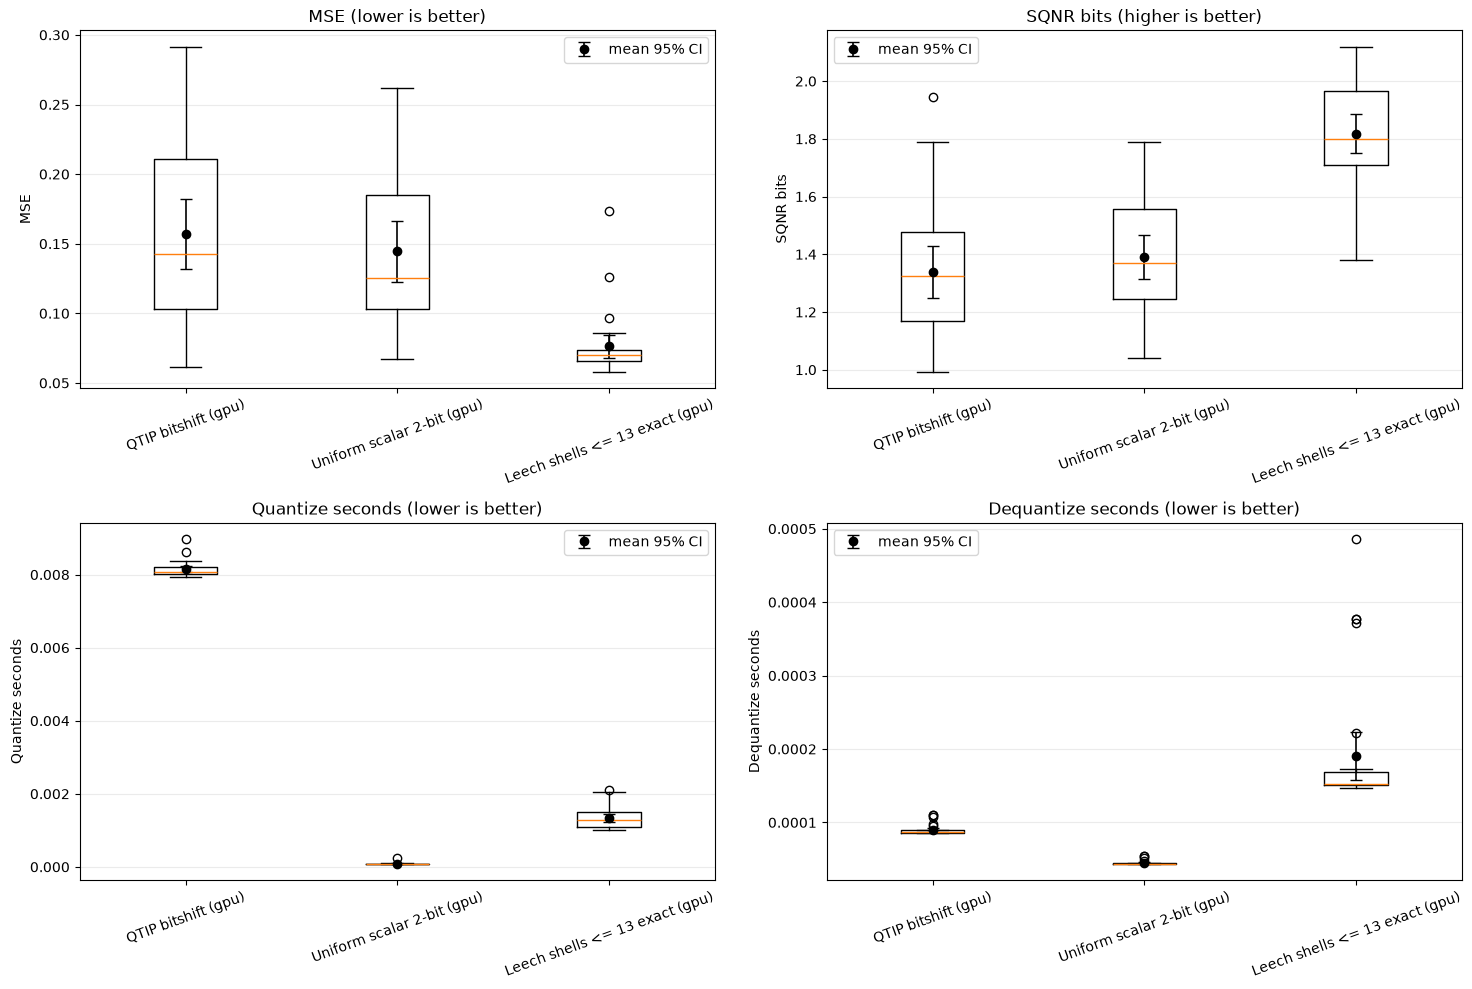

Pilot metric distributions with fitted normal references


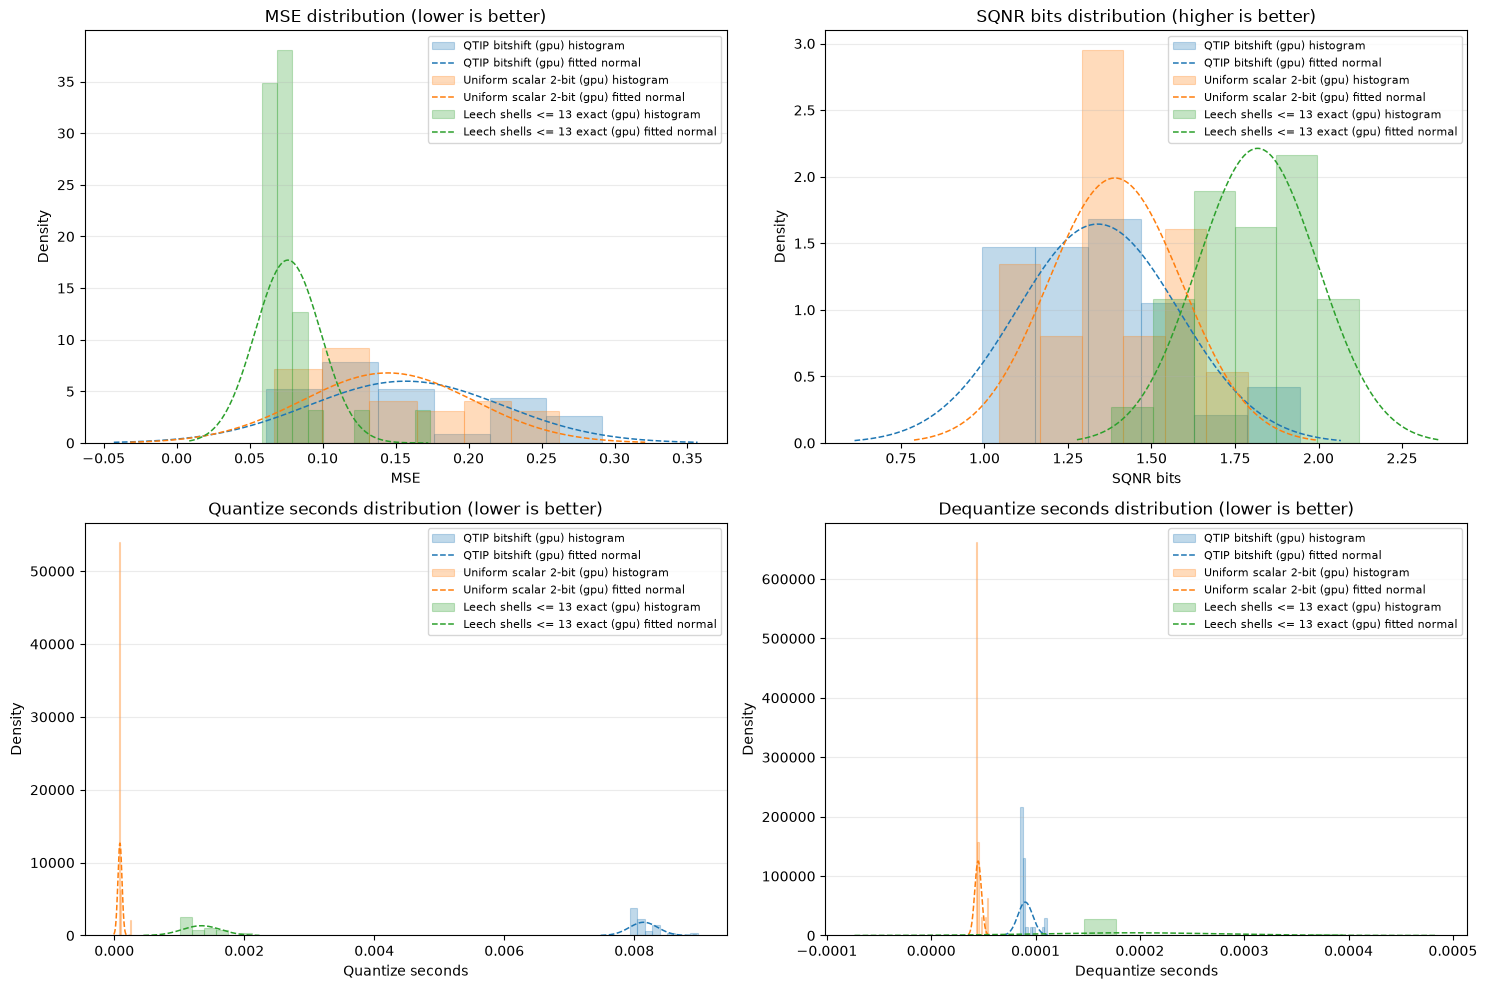

In [101]:
seed_everything(SEED)
pilot_rng = make_rng(1)
PILOT_N = max(PILOT_QUALITY_N, PILOT_TIMING_REPEATS)
pilot_batch_n = PILOT_N
pilot_x = pilot_rng.standard_normal((pilot_batch_n, DIM)).astype(np.float32)
quantizer_items, qtip_status = make_quantizer_items()
print(f"Using pilot runs = {PILOT_N}")
print(f"QTIP status: {qtip_status}")
print("Algorithms:")
for item in quantizer_items:
    print(f"- {item['method']} | rate={item['rate']:.3f} bpd")

pilot_csv, pilot_quality_sqnr, pilot_quantize_seconds, pilot_dequantize_seconds, pilot_reports = run_combined_experiment(
    quantizer_items,
    pilot_x,
    phase="pilot",
    n_runs=PILOT_N,
    warmup=TIMING_WARMUP_REPEATS,
    order_seed=SEED + 10,
)

pilot_results = reports_table(pilot_reports)
pilot_data_statistics = final_data_statistics_from_csv(pilot_csv, confidence=0.95)

pilot_quality_sqnr_from_csv = load_metric_samples_from_experiment_csv(pilot_csv, "sqnr_bits")
pilot_quantize_seconds_from_csv = load_metric_samples_from_experiment_csv(pilot_csv, "quantize_seconds")
pilot_dequantize_seconds_from_csv = load_metric_samples_from_experiment_csv(pilot_csv, "dequantize_seconds")
pilot_metric_samples = {
    "sqnr_bits": {
        "samples": pilot_quality_sqnr_from_csv,
        "sample_unit": "vectors",
        "higher_is_better": True,
    },
    "quantize_seconds": {
        "samples": pilot_quantize_seconds_from_csv,
        "sample_unit": "timing_repeats",
        "higher_is_better": False,
    },
    "dequantize_seconds": {
        "samples": pilot_dequantize_seconds_from_csv,
        "sample_unit": "timing_repeats",
        "higher_is_better": False,
    },
}
pilot_assumption_check_table = anova_assumption_checks(pilot_metric_samples)
pilot_normality_check_table = pilot_assumption_check_table[
    pilot_assumption_check_table["assumption"].eq("normality_of_rm_anova_residuals")
].reset_index(drop=True)

print(f"Pilot CSV: {pilot_csv}")
print("Pilot summary")
display(pilot_results)
print("Pilot data statistics")
display(pilot_data_statistics)
print("Pilot normality checks")
display(pilot_normality_check_table)
print("Pilot metric boxplots with mean 95% confidence intervals")
pilot_metric_boxplot_figure = plot_metric_boxplots_with_ci(pilot_csv, pilot_data_statistics)
plt.show()
print("Pilot metric distributions with fitted normal references")
pilot_metric_distribution_figure = plot_metric_distributions_with_normal_reference(pilot_csv)
plt.show()


## Parametric ANOVA sample size calculation

This block follows the Topic 06 ANOVA procedure for multiple means. It estimates the within-algorithm variance from the pilot CSV, evaluates the slide scenarios `two_levels_symmetric` and `one_vs_rest`, and chooses the largest ANOVA omnibus sample size across SQNR, quantize time, and dequantize time.


In [ ]:
# Sample-size planning reads the pilot CSV back from disk after the pilot statistics, diagnostics, and plots.
pilot_sd_n = pilot_sample_size_for_sd(confidence=0.95, relative_error=0.25)
method_names = [item["method"] for item in quantizer_items]
planned_metrics = ["sqnr_bits", "quantize_seconds", "dequantize_seconds"]
planned_comparisons = planned_comparisons_table(method_names, planned_metrics, alpha_family=ALPHA)
alpha_pair, total_pairwise_tests = pairwise_alpha_for_scope(len(quantizer_items), ALPHA)

sample_size_procedure = pd.DataFrame([
    {
        "step": 1,
        "procedure": "Choose ANOVA effect scenarios",
        "notebook_value": ", ".join(ANOVA_EFFECT_SCENARIOS),
    },
    {
        "step": 2,
        "procedure": "Estimate within variance from the pilot data",
        "notebook_value": "one-way ANOVA within-group residual variance for each metric",
    },
    {
        "step": 3,
        "procedure": "Calculate omnibus ANOVA F-test power",
        "notebook_value": "noncentral F distribution with df1=a-1 and df2=a(n-1)",
    },
    {
        "step": 4,
        "procedure": "Find smallest n per algorithm reaching target power",
        "notebook_value": f"alpha={ALPHA}, power={POWER}",
    },
    {
        "step": 5,
        "procedure": "Use the largest required sample size",
        "notebook_value": "one shared final n across metrics and ANOVA scenarios",
    },
])

quality_anova_sample_size_table = anova_sample_size_table_from_samples(
    pilot_quality_sqnr_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_SQNR_BITS_DIFF,
    metric="sqnr_bits",
    sample_unit="vectors",
)
quantize_time_anova_sample_size_table = anova_sample_size_table_from_samples(
    pilot_quantize_seconds_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_QUANTIZE_SECONDS,
    metric="quantize_seconds",
    sample_unit="timing_repeats",
)
dequantize_time_anova_sample_size_table = anova_sample_size_table_from_samples(
    pilot_dequantize_seconds_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_DEQUANTIZE_SECONDS,
    metric="dequantize_seconds",
    sample_unit="timing_repeats",
)

anova_sample_size_table = pd.concat(
    [
        quality_anova_sample_size_table,
        quantize_time_anova_sample_size_table,
        dequantize_time_anova_sample_size_table,
    ],
    ignore_index=True,
)

REQUIRED_QUALITY_N = required_anova_n_from_table(quality_anova_sample_size_table)
REQUIRED_QUANTIZE_REPEATS = required_anova_n_from_table(quantize_time_anova_sample_size_table)
REQUIRED_DEQUANTIZE_REPEATS = required_anova_n_from_table(dequantize_time_anova_sample_size_table)
EXPERIMENT_N = int(max(REQUIRED_QUALITY_N, REQUIRED_QUANTIZE_REPEATS, REQUIRED_DEQUANTIZE_REPEATS))
TIMING_REPEATS = EXPERIMENT_N

quality_anova_sample_size_table = add_anova_planned_power(quality_anova_sample_size_table, EXPERIMENT_N)
quantize_time_anova_sample_size_table = add_anova_planned_power(quantize_time_anova_sample_size_table, TIMING_REPEATS)
dequantize_time_anova_sample_size_table = add_anova_planned_power(dequantize_time_anova_sample_size_table, TIMING_REPEATS)
anova_sample_size_table = pd.concat(
    [
        quality_anova_sample_size_table,
        quantize_time_anova_sample_size_table,
        dequantize_time_anova_sample_size_table,
    ],
    ignore_index=True,
)

sample_size_summary = pd.DataFrame([
    {
        "metric": "sqnr_bits",
        "sample_unit": "vectors",
        "pilot_samples_per_algorithm": PILOT_N,
        "required_samples_per_algorithm": REQUIRED_QUALITY_N,
        "planned_samples_per_algorithm": EXPERIMENT_N,
        "minimum_interesting_difference": MIN_INTERESTING_SQNR_BITS_DIFF,
        "family_alpha": ALPHA,
        "power": POWER,
        "calculation": "anova_omnibus_f_test",
    },
    {
        "metric": "quantize_seconds",
        "sample_unit": "timing_repeats",
        "pilot_samples_per_algorithm": PILOT_N,
        "required_samples_per_algorithm": REQUIRED_QUANTIZE_REPEATS,
        "planned_samples_per_algorithm": TIMING_REPEATS,
        "minimum_interesting_difference": MIN_INTERESTING_QUANTIZE_SECONDS,
        "family_alpha": ALPHA,
        "power": POWER,
        "calculation": "anova_omnibus_f_test",
    },
    {
        "metric": "dequantize_seconds",
        "sample_unit": "timing_repeats",
        "pilot_samples_per_algorithm": PILOT_N,
        "required_samples_per_algorithm": REQUIRED_DEQUANTIZE_REPEATS,
        "planned_samples_per_algorithm": TIMING_REPEATS,
        "minimum_interesting_difference": MIN_INTERESTING_DEQUANTIZE_SECONDS,
        "family_alpha": ALPHA,
        "power": POWER,
        "calculation": "anova_omnibus_f_test",
    },
])

# Secondary check only: post-hoc pairwise planning usually requires larger n than ANOVA-only planning.
quality_sample_size_table = add_planned_power(sample_size_table_from_samples(
    pilot_quality_sqnr_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_SQNR_BITS_DIFF,
    metric="sqnr_bits",
    sample_unit="vectors",
), EXPERIMENT_N)
quantize_time_sample_size_table = add_planned_power(sample_size_table_from_samples(
    pilot_quantize_seconds_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_QUANTIZE_SECONDS,
    metric="quantize_seconds",
    sample_unit="timing_repeats",
), TIMING_REPEATS)
dequantize_time_sample_size_table = add_planned_power(sample_size_table_from_samples(
    pilot_dequantize_seconds_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_DEQUANTIZE_SECONDS,
    metric="dequantize_seconds",
    sample_unit="timing_repeats",
), TIMING_REPEATS)
posthoc_sample_size_table = pd.concat(
    [quality_sample_size_table, quantize_time_sample_size_table, dequantize_time_sample_size_table],
    ignore_index=True,
)

print(f"Pilot-study approximation for SD estimate: n ~= {pilot_sd_n} for 95% confidence and 25% relative error")
print(f"Using PILOT_QUALITY_N = {PILOT_QUALITY_N}")
print(f"ANOVA scenarios: {', '.join(ANOVA_EFFECT_SCENARIOS)}")
print(f"Required quality vectors per algorithm: {REQUIRED_QUALITY_N}")
print(f"Required quantize timing runs per algorithm: {REQUIRED_QUANTIZE_REPEATS}")
print(f"Required dequantize timing runs per algorithm: {REQUIRED_DEQUANTIZE_REPEATS}")
print(f"Final shared experiment runs per algorithm: {EXPERIMENT_N}")
print(f"Post-hoc adjusted alpha per comparison for secondary check: {alpha_pair:.6g}")

print("Topic 06 ANOVA sample-size procedure")
display(sample_size_procedure)
print("ANOVA omnibus sample-size summary")
display(sample_size_summary)
print("ANOVA omnibus sample-size details")
display(anova_sample_size_table)
print("Planned post-hoc comparisons and adjusted alpha, secondary check")
display(planned_comparisons)
print("Post-hoc pairwise sample-size check, not used for EXPERIMENT_N")
posthoc_sample_size_table


## Final experiment

The final run uses one shared `EXPERIMENT_N`, chosen as the largest ANOVA omnibus sample size across SQNR, quantize time, and dequantize time. Each block evaluates every algorithm once on one vector and records MSE, SQNR, quantize time, and dequantize time in the same CSV row.


In [ ]:
seed_everything(SEED)
final_rng = make_rng(101)
X = final_rng.standard_normal((EXPERIMENT_N, DIM)).astype(np.float32)

data_csv, quality_scores_from_csv, quantize_times_from_csv, dequantize_times_from_csv, reports = run_combined_experiment(
    quantizer_items,
    X,
    phase="final",
    n_runs=EXPERIMENT_N,
    warmup=TIMING_WARMUP_REPEATS,
    order_seed=SEED + 110,
)

# Statistical inference below intentionally reloads the saved final CSV file.
quality_scores_from_csv = load_metric_samples_from_experiment_csv(data_csv, "sqnr_bits")
quantize_times_from_csv = load_metric_samples_from_experiment_csv(data_csv, "quantize_seconds")
dequantize_times_from_csv = load_metric_samples_from_experiment_csv(data_csv, "dequantize_seconds")

final_table = reports_table(reports)
final_quality_sample_size_check = add_anova_planned_power(anova_sample_size_table_from_samples(
    quality_scores_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_SQNR_BITS_DIFF,
    metric="sqnr_bits",
    sample_unit="vectors",
), EXPERIMENT_N)
final_quantize_time_sample_size_check = add_anova_planned_power(anova_sample_size_table_from_samples(
    quantize_times_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_QUANTIZE_SECONDS,
    metric="quantize_seconds",
    sample_unit="timing_repeats",
), EXPERIMENT_N)
final_dequantize_time_sample_size_check = add_anova_planned_power(anova_sample_size_table_from_samples(
    dequantize_times_from_csv,
    alpha=ALPHA,
    power=POWER,
    delta=MIN_INTERESTING_DEQUANTIZE_SECONDS,
    metric="dequantize_seconds",
    sample_unit="timing_repeats",
), EXPERIMENT_N)

final_timing_summary = pd.DataFrame([
    {
        "method": name,
        "quantize_seconds_mean": float(np.mean(quantize_times_from_csv[name])),
        "quantize_seconds_std": float(np.std(quantize_times_from_csv[name], ddof=1)),
        "dequantize_seconds_mean": float(np.mean(dequantize_times_from_csv[name])),
        "dequantize_seconds_std": float(np.std(dequantize_times_from_csv[name], ddof=1)),
        "timing_repeats": EXPERIMENT_N,
        "timing_batch_n": 1,
    }
    for name in quantize_times_from_csv
])

final_data_statistics = final_data_statistics_from_csv(data_csv, confidence=0.95)

metric_samples = {
    "sqnr_bits": {
        "samples": quality_scores_from_csv,
        "sample_unit": "vectors",
        "higher_is_better": True,
    },
    "quantize_seconds": {
        "samples": quantize_times_from_csv,
        "sample_unit": "timing_repeats",
        "higher_is_better": False,
    },
    "dequantize_seconds": {
        "samples": dequantize_times_from_csv,
        "sample_unit": "timing_repeats",
        "higher_is_better": False,
    },
}

assumption_check_table = anova_assumption_checks(metric_samples)
global_test_table = global_multiple_sample_tests(metric_samples)
friedman_test_table = global_test_table[global_test_table["test"].eq("friedman")].reset_index(drop=True)
posthoc_table = posthoc_pairwise_table(metric_samples)

print(f"Final data CSV: {data_csv}")
print("Statistical inference loaded observations from the final CSV file.")
final_table


In [ ]:
print(f"Pilot CSV: {pilot_csv}")
print(f"Final data CSV: {data_csv}")
# Multiple-sample tests and corrected post-hoc comparisons from the final run.
print("Metric boxplots with mean 95% confidence intervals")
metric_boxplot_figure = plot_metric_boxplots_with_ci(data_csv, final_data_statistics)
plt.show()
print("Metric distributions with fitted normal references")
metric_distribution_figure = plot_metric_distributions_with_normal_reference(data_csv)
plt.show()
print("Final data statistics")
display(final_data_statistics)
print("ANOVA assumption checks")
display(assumption_check_table)
print("Global multiple-sample tests")
display(global_test_table)
print("Friedman tests")
display(friedman_test_table)
print("Bonferroni-corrected post-hoc paired comparisons")
display(posthoc_table)
print("ANOVA quality sample-size check")
display(final_quality_sample_size_check)
print("ANOVA quantize-time sample-size check")
display(final_quantize_time_sample_size_check)
print("ANOVA dequantize-time sample-size check")
display(final_dequantize_time_sample_size_check)
print("Timing summary")
display(final_timing_summary)


## Normality versus sample size

This diagnostic reruns the residual normality check on increasing prefixes of the final paired blocks. It helps show whether the ANOVA residual normality check passes or fails as the available sample size grows.

Normality progression summary


,metric,sample_unit,first_passing_n,largest_passing_n,full_n,full_n_p_value,alpha,passes_at_full_n
0,sqnr_bits,vectors,5.0,250.0,250,9.556121e-02,0.05,True
1,quantize_seconds,timing_repeats,5.0,50.0,250,2.714314e-05,0.05,False
2,dequantize_seconds,timing_repeats,NaN,NaN,250,2.225930e-31,0.05,False


Normality progression by sample size


,metric,sample_unit,n_blocks,n_residuals,test,statistic,p_value,alpha,passes_alpha,note
0,sqnr_bits,vectors,5,15,shapiro_wilk,0.947179,4.811679e-01,0.05,True,ok
1,sqnr_bits,vectors,10,30,shapiro_wilk,0.961695,3.420093e-01,0.05,True,ok
2,sqnr_bits,vectors,15,45,shapiro_wilk,0.978518,5.609108e-01,0.05,True,ok
3,sqnr_bits,vectors,20,60,shapiro_wilk,0.979511,4.082074e-01,0.05,True,ok
4,sqnr_bits,vectors,25,75,shapiro_wilk,0.970855,8.098393e-02,0.05,True,ok
5,sqnr_bits,vectors,30,90,shapiro_wilk,0.988913,6.510369e-01,0.05,True,ok
6,sqnr_bits,vectors,40,120,shapiro_wilk,0.988921,4.429869e-01,0.05,True,ok
7,sqnr_bits,vectors,50,150,shapiro_wilk,0.989835,3.517666e-01,0.05,True,ok
8,sqnr_bits,vectors,60,180,shapiro_wilk,0.990182,2.533099e-01,0.05,True,ok
9,sqnr_bits,vectors,75,225,shapiro_wilk,0.991810,2.414010e-01,0.05,True,ok


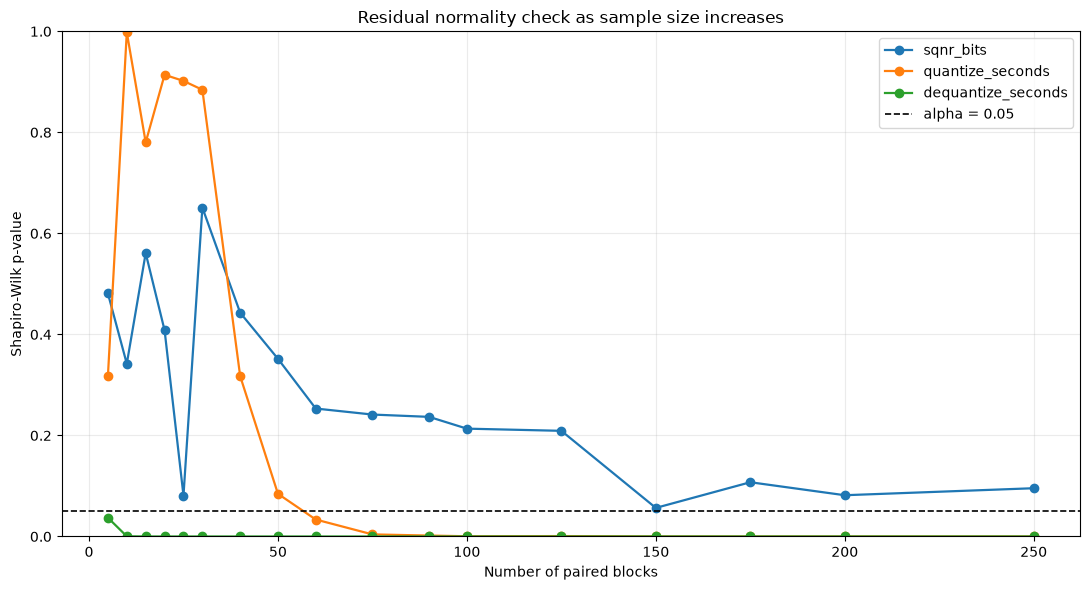

In [106]:
def normality_progression_candidate_ns(n_blocks: int) -> list[int]:
    base = [
        5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 90, 100, 125, 150, 175, 200,
        250, 300, 400, 500, 750, 1000, 1250, 1500, 1750, 2000,
    ]
    values = [n for n in base if 3 <= n <= int(n_blocks)]
    if int(n_blocks) not in values:
        values.append(int(n_blocks))
    return sorted(set(values))


def normality_progression_table(metric_samples: dict[str, dict[str, np.ndarray]], alpha: float = ALPHA) -> pd.DataFrame:
    rows = []
    for metric, spec in metric_samples.items():
        samples = spec["samples"]
        names, y = sample_matrix(samples)
        for n_blocks in normality_progression_candidate_ns(y.shape[0]):
            prefix_samples = {name: y[:n_blocks, idx] for idx, name in enumerate(names)}
            residuals = repeated_measures_residuals(prefix_samples)
            statistic, p_value, note = safe_shapiro(residuals)
            rows.append({
                "metric": metric,
                "sample_unit": spec["sample_unit"],
                "n_blocks": int(n_blocks),
                "n_residuals": int(residuals.size),
                "test": "shapiro_wilk",
                "statistic": statistic,
                "p_value": p_value,
                "alpha": float(alpha),
                "passes_alpha": bool(p_value >= alpha) if math.isfinite(p_value) else None,
                "note": note,
            })
    return pd.DataFrame(rows)


def normality_progression_summary(progress_table: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for metric, group in progress_table.groupby("metric", sort=False):
        group = group.sort_values("n_blocks")
        passing = group[group["passes_alpha"].eq(True)]
        full_row = group.iloc[-1]
        rows.append({
            "metric": metric,
            "sample_unit": full_row["sample_unit"],
            "first_passing_n": int(passing.iloc[0]["n_blocks"]) if not passing.empty else float("nan"),
            "largest_passing_n": int(passing.iloc[-1]["n_blocks"]) if not passing.empty else float("nan"),
            "full_n": int(full_row["n_blocks"]),
            "full_n_p_value": float(full_row["p_value"]),
            "alpha": float(full_row["alpha"]),
            "passes_at_full_n": bool(full_row["passes_alpha"]),
        })
    return pd.DataFrame(rows)


def plot_normality_progression(progress_table: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(11, 6))
    for metric, group in progress_table.groupby("metric", sort=False):
        group = group.sort_values("n_blocks")
        ax.plot(group["n_blocks"], group["p_value"], marker="o", linewidth=1.6, label=metric)
    alpha_value = float(progress_table["alpha"].iloc[0]) if len(progress_table) else ALPHA
    ax.axhline(alpha_value, color="black", linestyle="--", linewidth=1.2, label=f"alpha = {alpha_value:g}")
    ax.set_xlabel("Number of paired blocks")
    ax.set_ylabel("Shapiro-Wilk p-value")
    ax.set_title("Residual normality check as sample size increases")
    ax.set_ylim(bottom=0.0, top=1.0)
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()
    return fig


normality_vs_n_table = normality_progression_table(metric_samples, alpha=ALPHA)
normality_vs_n_summary = normality_progression_summary(normality_vs_n_table)

print("Normality progression summary")
display(normality_vs_n_summary)
print("Normality progression by sample size")
display(normality_vs_n_table)
normality_vs_n_figure = plot_normality_progression(normality_vs_n_table)
plt.show()
